In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('/content/customer_behavior.csv')
df

,CustomerID,Gender,Region,PurchaseAmount,ProductCategory,Churn,CampaignGroup
0,1001,Male,South,256.07,Fashion,No,A
1,1002,Female,South,NaN,Electronics,Yes,B
2,1003,Female,West,1194.41,Fashion,No,A
3,1004,Female,South,413.06,Grocery,No,A
4,1005,Male,West,1556.32,Fashion,Yes,A
...,...,...,...,...,...,...,...
4995,5996,Female,West,1497.00,Electronics,Yes,B
4996,5997,Male,West,978.87,Fashion,Yes,A
4997,5998,Male,West,906.93,Fashion,No,NaN
4998,5999,Female,South,375.67,Fashion,No,NaN


In [ ]:
df.shape

(5000, 7)

In [ ]:
df.isnull().sum()

,0
CustomerID,0
Gender,97
Region,175
PurchaseAmount,150
ProductCategory,526
Churn,265
CampaignGroup,185


1. What is the average, median, and mode of PurchaseAmount?

In [ ]:
# There are 150 missing values in the purchase amount
print(df['PurchaseAmount'].mean())
print(df['PurchaseAmount'].median())
print(df['PurchaseAmount'].mode())

1003.9506701030928
998.0799999999999
0    0.0
Name: PurchaseAmount, dtype: float64


In [ ]:
df['PurchaseAmount'].value_counts()

,count
PurchaseAmount,
0.00,102
1018.78,3
344.23,2
1029.95,2
1141.96,2
...,...
1733.22,1
830.67,1
458.99,1


In [ ]:
#filling the missing value in the  PurchaseAmount by median
df['PurchaseAmount'].fillna(df['PurchaseAmount'].median(),inplace=True)

/tmp/ipython-input-1428959892.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['PurchaseAmount'].fillna(df['PurchaseAmount'].median(),inplace=True)


In [ ]:
#new mean and median after filling missing values
print(df['PurchaseAmount'].mean())
print(df['PurchaseAmount'].median())

1003.77455
998.0799999999999


In [ ]:
df.isnull().sum()

,0
CustomerID,0
Gender,97
Region,175
PurchaseAmount,0
ProductCategory,526
Churn,265
CampaignGroup,185


2. Are there any outliers in the PurchaseAmount data?

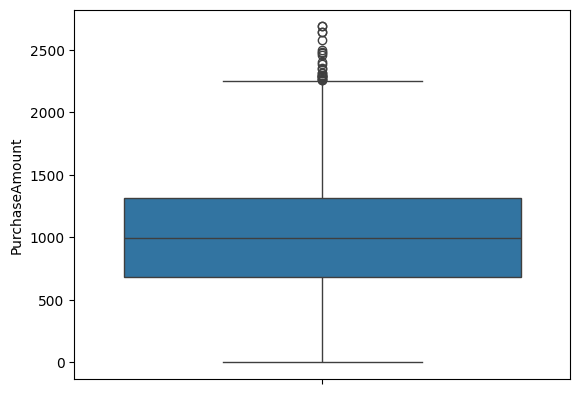

In [ ]:
sns.boxplot(df['PurchaseAmount'])
plt.show() # from the boxplot we can understand that there are outliers

In [ ]:
Q1,Q3=np.percentile(df['PurchaseAmount'],[25,75])
print(Q1,'is first quartile')
print(Q3,'is third quartile')

686.395 is first quartile
1316.155 is third quartile


In [ ]:
iqr=Q3-Q1
print(iqr,'is iqr')

629.76 is iqr


In [ ]:
lower_bound=Q1-(1.5*iqr)
upper_bound=Q3+(1.5*iqr)
print(lower_bound,'is lower bound')
print(upper_bound,'is upper bound')
outliers=df[(df['PurchaseAmount']<lower_bound) | (df['PurchaseAmount']>upper_bound)]
outliers

-258.245 is lower bound
2260.795 is upper bound


,CustomerID,Gender,Region,PurchaseAmount,ProductCategory,Churn,CampaignGroup
195,1196,Male,West,2318.33,Fashion,Yes,B
265,1266,Female,East,2496.41,Electronics,Yes,B
348,1349,Male,South,2688.69,Electronics,Yes,A
411,1412,Female,South,2349.16,Fashion,Yes,A
442,1443,Male,North,2291.79,Grocery,Yes,B
702,1703,Male,East,2292.99,Fashion,Yes,B
826,1827,Male,East,2578.89,Electronics,Yes,B
1358,2359,Male,West,2384.19,Electronics,Yes,A
1792,2793,Female,South,2265.18,Grocery,No,B
2285,3286,Male,East,2457.05,Grocery,No,B


In [ ]:
#Z-Score

def detect_outliers(series):
    outliers = []
    threshold = 3

    mean = np.mean(series)
    std = np.std(series)

    print("Mean:", mean)
    print("Std:", std)

    for value in series:
        z_score = (value - mean) / std
        #print("Z-score:", z_score)

        if abs(z_score) > threshold:
            outliers.append(value)

    return outliers


In [ ]:
outliers = detect_outliers(df['PurchaseAmount'])
outliers


Mean: 1003.77455
Std: 474.7784607394883


[2496.41,
 2688.69,
 2578.89,
 2457.05,
 2688.88,
 2643.88,
 2472.62,
 2484.75,
 2642.06]

In [ ]:
#3. Is there any skewness or kurtosis in the PurchaseAmount distribution?
skewness=df['PurchaseAmount'].skew()
skewness
if skewness > 0:
    print("The distribution is positively skewed.")
elif(skewness < 0):
    print("The distribution is negatively skewed.")
elif(skewness>=0.5 and skewness<=0.5):
  print('Approximately symmetric')
elif(skewness>0.5 and skewness<1):
  print('Slightly skewed to the right')
else:
  print('Slightly skewed to the left')

The distribution is positively skewed.


since the skewness value is very close to zero we can say that the distribution in close to normal distribution

In [ ]:
from scipy import stats

In [ ]:
#4. Is there a significant difference in spending between male and female customers?
#Ho: There is significant difference in spending between male and female customers
#H1:There is no significant difference in spending between male and female customers

In [ ]:
alpha=0.05
male_spending=df[df['Gender']=='Male']['PurchaseAmount']
female_spending=df[df['Gender']=='Female']['PurchaseAmount']
#Since the population sd is unknown we use t test
#Since Gender has 2 groups (Male vs Female) and PurchaseAmount is numeric we use independent sample t test
t_stat, p_value = stats.ttest_ind(male_spending, female_spending, equal_var=False)
print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 2.2353512560108246
P-value: 0.025439175911167306


In [ ]:
if p_value < alpha:
    print("Reject the null hypothesis. There is a significant difference in spending between male and female customers.")
else:
    print("Fail to reject the null hypothesis. There is no significant difference in spending between male and female customers.")

Reject the null hypothesis. There is a significant difference in spending between male and female customers.


In [ ]:
#5. Is there a relationship between ProductCategory and customer churn?
#since both are categorical data we use chi square test
#H0: There is no relationship between ProductCategory and customer churn
#H1:There is  relationship between ProductCategory and customer churn

In [ ]:
from scipy.stats import chi2_contingency

In [ ]:
df1=pd.crosstab(df['ProductCategory'],df['Churn'])
df1

Churn,No,Yes
ProductCategory,,
Electronics,785,541
Fashion,839,607
Grocery,855,604


In [ ]:
chi2,p_value,dof,expected=chi2_contingency(df1)

In [ ]:
chi2

np.float64(0.3960436652673918)

In [ ]:
p_value

np.float64(0.8203519424988512)

In [ ]:
expected

array([[776.9212952 , 549.0787048 ],
       [847.23091468, 598.76908532],
       [854.84779012, 604.15220988]])

In [ ]:
alpha=0.05

In [ ]:
if p_value < alpha:
    print("Reject the null hypothesis. There is a relationship between ProductCategory and customer churn.")
else:
    print("Fail to reject the null hypothesis. There is no relationship between ProductCategory and customer churn.")

Fail to reject the null hypothesis. There is no relationship between ProductCategory and customer churn.


In [ ]:
#6. Does PurchaseAmount vary significantly across different regions?
#since purchase amount is numerical and region is categorical column we use oneway anova

In [ ]:
from scipy.stats import f_oneway


In [ ]:
df.isnull().sum()

,0
CustomerID,0
Gender,97
Region,175
PurchaseAmount,0
ProductCategory,526
Churn,265
CampaignGroup,185


In [ ]:
df['Region'].mode()

,Region
0,South


In [ ]:
df['Region'].fillna(df['Region'].mode()[0],inplace=True)

/tmp/ipython-input-2684117277.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Region'].fillna(df['Region'].mode()[0],inplace=True)


In [ ]:
df['Region'].value_counts()

,count
Region,
South,1423
East,1226
North,1211
West,1140


In [ ]:
region=df['Region'].unique()
region

array(['South', 'West', 'North', 'East'], dtype=object)

In [ ]:
groups = [df[df['Region']==r]['PurchaseAmount'] for r in region]
f_stats,p_value=f_oneway(*groups)
print("F-statistic:", f_stats)
print("P-value:", p_value)

F-statistic: 0.3865658263408036
P-value: 0.762690305503975


In [ ]:
alpha=0.05

In [ ]:
if p_value<alpha:
  print('Reject the null hypothesis. PurchaseAmount varies significantly across different regions.')
else:
  print('Fail to reject the null hypothesis-No significant variation')

Fail to reject the null hypothesis-No significant variation


In [ ]:
#7. Which email campaign (A or B) performed better in terms of average PurchaseAmount?
#here we need to compare one numerical variable with categorical variable so we will use independent t test
campaign_A = df[df['CampaignGroup']=='A']['PurchaseAmount']
campaign_B = df[df['CampaignGroup']=='B']['PurchaseAmount']


In [ ]:
t_stat, p_value = stats.ttest_ind(campaign_A, campaign_B, equal_var=False)

print("T-statistic:", t_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Reject H0 → Significant difference in average PurchaseAmount.")
else:
    print("Fail to reject H0 → No significant difference.")

T-statistic: 1.2393723137529187
P-value: 0.2152681941847301
Fail to reject H0 → No significant difference.


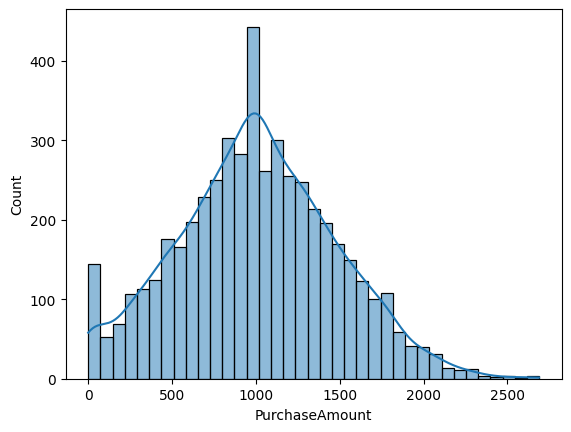

In [ ]:
#8. Can we assume PurchaseAmount follows a normal distribution?
sns.histplot(df['PurchaseAmount'],kde=True)
plt.show()
# from the graph we can uderstand that the data approximately follows a  normal distribution


In [ ]:
skewness=df['PurchaseAmount'].skew()
print('skewness is',skewness)

skewness is 0.10883141246252831


In [ ]:
k=df['PurchaseAmount'].kurtosis()
print('kurtosis is ',k)

kurtosis is  -0.17665360565282562


The skewness (0.1088) and kurtosis (–0.1767) values are within the acceptable range (–1 to +1), and the histogram shows an approximately bell-shaped curve. Therefore, the PurchaseAmount variable can be reasonably assumed to follow a normal distribution

In [ ]:
#9. What insights can we gain by applying the Central Limit Theorem?


In [ ]:
n=1000#sample size
num=1000 #no of samples
sample_means=[]
for i in range(num):
  sample=np.random.choice(df['PurchaseAmount'],size=n,replace=True)
  sample_mean=sample.mean()
  sample_means.append(sample_mean)


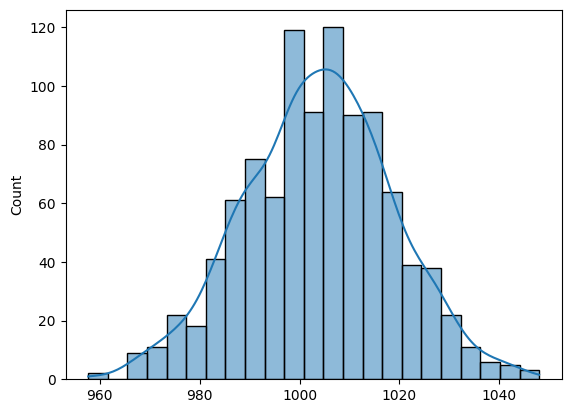

In [ ]:
sns.histplot(sample_means,kde=True)
plt.show()

In [ ]:
df1=pd.DataFrame(sample_means)
df1.skew()

,0
0,-0.038366


In [ ]:
df1.kurtosis()

,0
0,-0.057361


By Applying central limit theorem to the PurchaseAmount variable, the distribution of the sample mean PurchaseAmount becomes approximately normal.Even the population disturibution is not normal we can convert the samplesto perfectly normal distribution.Here skewness of purchase amount is 0.10883141246252831 where as skewness of sample mean is 0.053424,which is more close to zero.so we can say that the graph of sample means is more symmetric.

In [ ]:
#sample_means

In [ ]:
#10.What is the 95% confidence interval for the average PurchaseAmount?


In [ ]:
data=df['PurchaseAmount']
mean=np.mean(data)
std=np.std(data)
n=len(data)
standard_error=std/np.sqrt(n)
t_value=stats.t.ppf(0.975,n-1)
lower_bound=mean-t_value*standard_error
upper_bound=mean+t_value*standard_error
print('95% confidence interval is',lower_bound,'to',upper_bound)


95% confidence interval is 990.6114172483342 to 1016.9376827516658


Based on the 95% confidence interval, we can conclude that the true average PurchaseAmount is expected to lie between ₹990.61 and ₹1,016.94 with 95% confidence